<a href="https://www.kaggle.com/code/lalit7881/uber-ride-analytics-using-sql?scriptVersionId=304096718" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Basic libraries
import numpy as np
import pandas as pd
import sqlite3
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Advanced models
import xgboost as xgb
import lightgbm as lgb

# Plot settings
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

print("Libraries loaded successfully")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Libraries loaded successfully
/kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
/kaggle/input/datasets/rockyt07/uber-sql-database/schema.sql


## Loading dataset

In [2]:
# Load SQL file
sql_file = "/kaggle/input/datasets/rockyt07/uber-sql-database/schema.sql"

# Create database connection
conn = sqlite3.connect(":memory:")

# Read and run SQL script
with open(sql_file, "r") as file:
    conn.executescript(file.read())

# Show tables in database
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

print("Tables loaded:", tables["name"].tolist())

Tables loaded: ['users', 'drivers', 'riders', 'locations', 'trips', 'payments', 'reviews', 'cancellations']


##  Load tables into DataFrames

In [3]:
# Load tables into DataFrames
users = pd.read_sql("SELECT * FROM users", conn)
drivers = pd.read_sql("SELECT * FROM drivers", conn)
riders = pd.read_sql("SELECT * FROM riders", conn)
locations = pd.read_sql("SELECT * FROM locations", conn)
trips = pd.read_sql("SELECT * FROM trips", conn)
payments = pd.read_sql("SELECT * FROM payments", conn)
reviews = pd.read_sql("SELECT * FROM reviews", conn)
cancellations = pd.read_sql("SELECT * FROM cancellations", conn)

# Print table shapes
tables = {
    "users": users,
    "drivers": drivers,
    "riders": riders,
    "locations": locations,
    "trips": trips,
    "payments": payments,
    "reviews": reviews,
    "cancellations": cancellations
}

for name, df in tables.items():
    print(name, ":", df.shape)

users : (2000, 7)
drivers : (400, 9)
riders : (1600, 5)
locations : (40, 6)
trips : (20000, 15)
payments : (16827, 6)
reviews : (15136, 7)
cancellations : (2966, 5)


## # Data Overview

In [4]:
print("TRIPS Data Types")
print(trips.dtypes)

print("\nMissing Values")
print(trips.isnull().sum())

print("\nSummary Statistics")
print(trips.describe())

TRIPS Data Types
trip_id                  int64
rider_id                 int64
driver_id                int64
pickup_location_id       int64
dropoff_location_id      int64
requested_at            object
started_at              object
completed_at            object
status                  object
distance_km            float64
duration_mins            int64
base_fare              float64
surge_multiplier       float64
total_fare             float64
payment_method          object
dtype: object

Missing Values
trip_id                   0
rider_id                  0
driver_id                 0
pickup_location_id        0
dropoff_location_id       0
requested_at              0
started_at                0
completed_at           3173
status                    0
distance_km               0
duration_mins             0
base_fare                 0
surge_multiplier          0
total_fare                0
payment_method            0
dtype: int64

Summary Statistics
            trip_id     rider_id   

In [5]:
trips.info()
trips.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trip_id              20000 non-null  int64  
 1   rider_id             20000 non-null  int64  
 2   driver_id            20000 non-null  int64  
 3   pickup_location_id   20000 non-null  int64  
 4   dropoff_location_id  20000 non-null  int64  
 5   requested_at         20000 non-null  object 
 6   started_at           20000 non-null  object 
 7   completed_at         16827 non-null  object 
 8   status               20000 non-null  object 
 9   distance_km          20000 non-null  float64
 10  duration_mins        20000 non-null  int64  
 11  base_fare            20000 non-null  float64
 12  surge_multiplier     20000 non-null  float64
 13  total_fare           20000 non-null  float64
 14  payment_method       20000 non-null  object 
dtypes: float64(4), int64(6), object(5)
m

,trip_id,rider_id,driver_id,pickup_location_id,dropoff_location_id,distance_km,duration_mins,base_fare,surge_multiplier,total_fare
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,808.04035,201.431950,20.123100,20.116850,18.013125,31.318850,28.578512,1.261648,36.008345
std,5773.647028,458.81708,114.642109,11.951405,11.998183,11.383895,20.164943,15.886229,0.533862,26.526153
min,1.000000,1.00000,1.000000,1.000000,1.000000,0.500000,3.000000,3.650000,1.000000,3.650000
25%,5000.750000,414.00000,101.000000,9.000000,9.000000,8.060000,14.000000,14.170000,1.000000,16.210000
50%,10000.500000,801.00000,207.000000,20.000000,20.000000,17.800000,30.000000,29.495000,1.000000,32.470000
75%,15000.250000,1226.00000,298.000000,31.000000,31.000000,25.340000,46.000000,39.642500,1.000000,45.242500
max,20000.000000,1571.00000,400.000000,40.000000,40.000000,60.180000,153.000000,88.100000,3.000000,224.270000


## Convert date columns

In [6]:
date_cols = ["requested_at", "started_at", "completed_at"]

for col in date_cols:
    trips[col] = pd.to_datetime(trips[col], errors="coerce")

## Calculate wait time

In [7]:
trips["wait_time_mins"] = (
    trips["started_at"] - trips["requested_at"]
).dt.total_seconds() / 60

## Calculate trip duration

In [8]:
trips["duration_mins"] = (
    trips["completed_at"] - trips["started_at"]
).dt.total_seconds() / 60

## Fare per kilometer

In [9]:
trips["fare_per_km"] = trips["total_fare"] / trips["distance_km"]

## Surge flag

In [10]:
trips["is_surge"] = (trips["surge_multiplier"] > 1).astype(int)

## Extract time features

In [11]:
trips["hour"] = trips["requested_at"].dt.hour
trips["day_of_week"] = trips["requested_at"].dt.dayofweek
trips["month"] = trips["requested_at"].dt.month
trips["year"] = trips["requested_at"].dt.year

## Peak hour flag

In [12]:
trips["is_peak_hour"] = trips["hour"].apply(
    lambda h: 1 if 7 <= h <= 9 or 17 <= h <= 19 else 0
)

# Weekend flag

In [13]:
trips["is_weekend"] = (trips["day_of_week"] >= 5).astype(int)

## Completed trip flag

In [14]:
trips["is_completed"] = (trips["status"] == "completed").astype(int)

## Preview data

In [15]:
print("Feature engineering complete")

trips[[
    "trip_id",
    "distance_km",
    "total_fare",
    "fare_per_km",
    "wait_time_mins",
    "is_surge",
    "is_peak_hour",
    "is_completed"
]].head()

Feature engineering complete


,trip_id,distance_km,total_fare,fare_per_km,wait_time_mins,is_surge,is_peak_hour,is_completed
0,1,39.14,68.55,1.751405,9.0,0,0,1
1,2,9.53,17.38,1.823715,2.0,0,0,0
2,3,2.78,6.36,2.287770,2.0,0,1,1
3,4,14.25,21.98,1.542456,5.0,0,1,1
4,5,41.54,56.99,1.371931,8.0,0,0,1


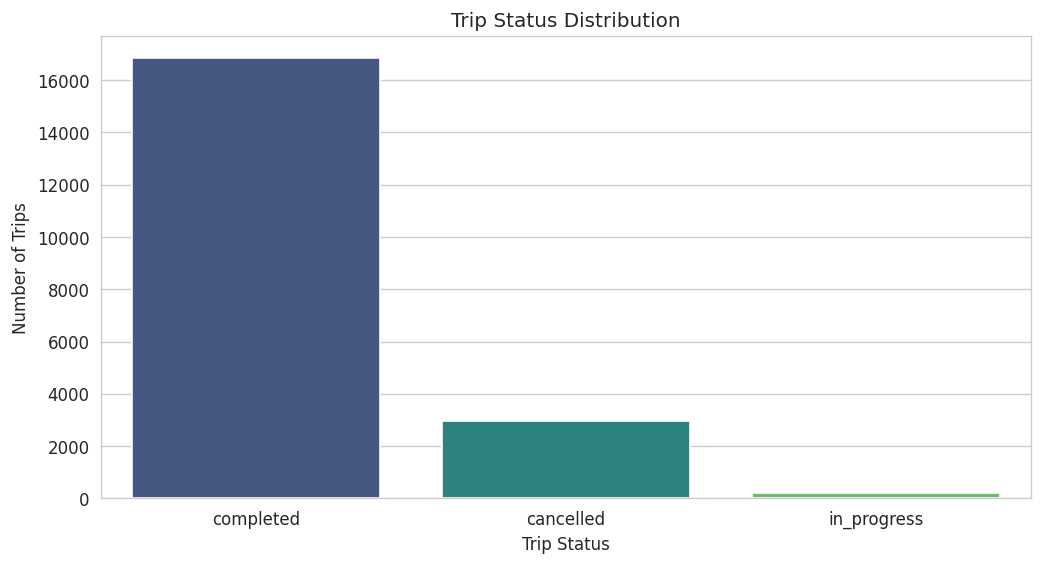

Completed trips: 16827 (84.1%)


In [16]:
# Trip Status Distribution

plt.figure(figsize=(10,5))

# Bar plot with different colors
sns.countplot(x="status", data=trips, palette="viridis")

plt.title("Trip Status Distribution")
plt.xlabel("Trip Status")
plt.ylabel("Number of Trips")

plt.show()

# Completion percentage
completed = trips["is_completed"].sum()
percent = trips["is_completed"].mean() * 100

print("Completed trips:", completed, f"({percent:.1f}%)")

<Axes: xlabel='status', ylabel='count'>

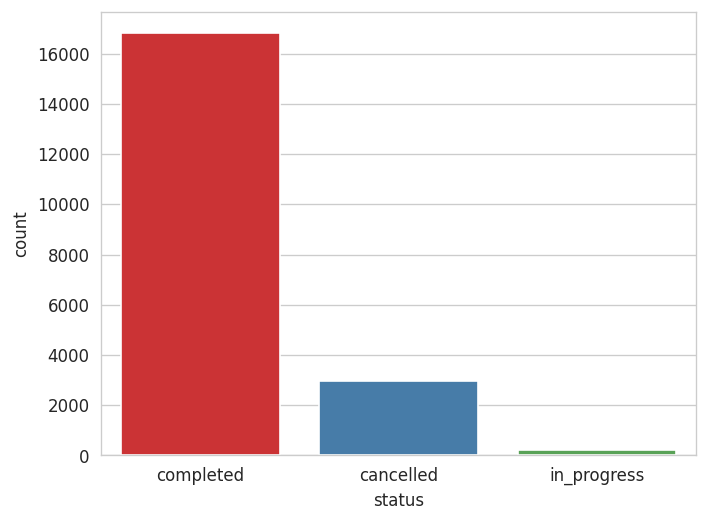

In [17]:
sns.countplot(x="status", data=trips, palette="Set1")

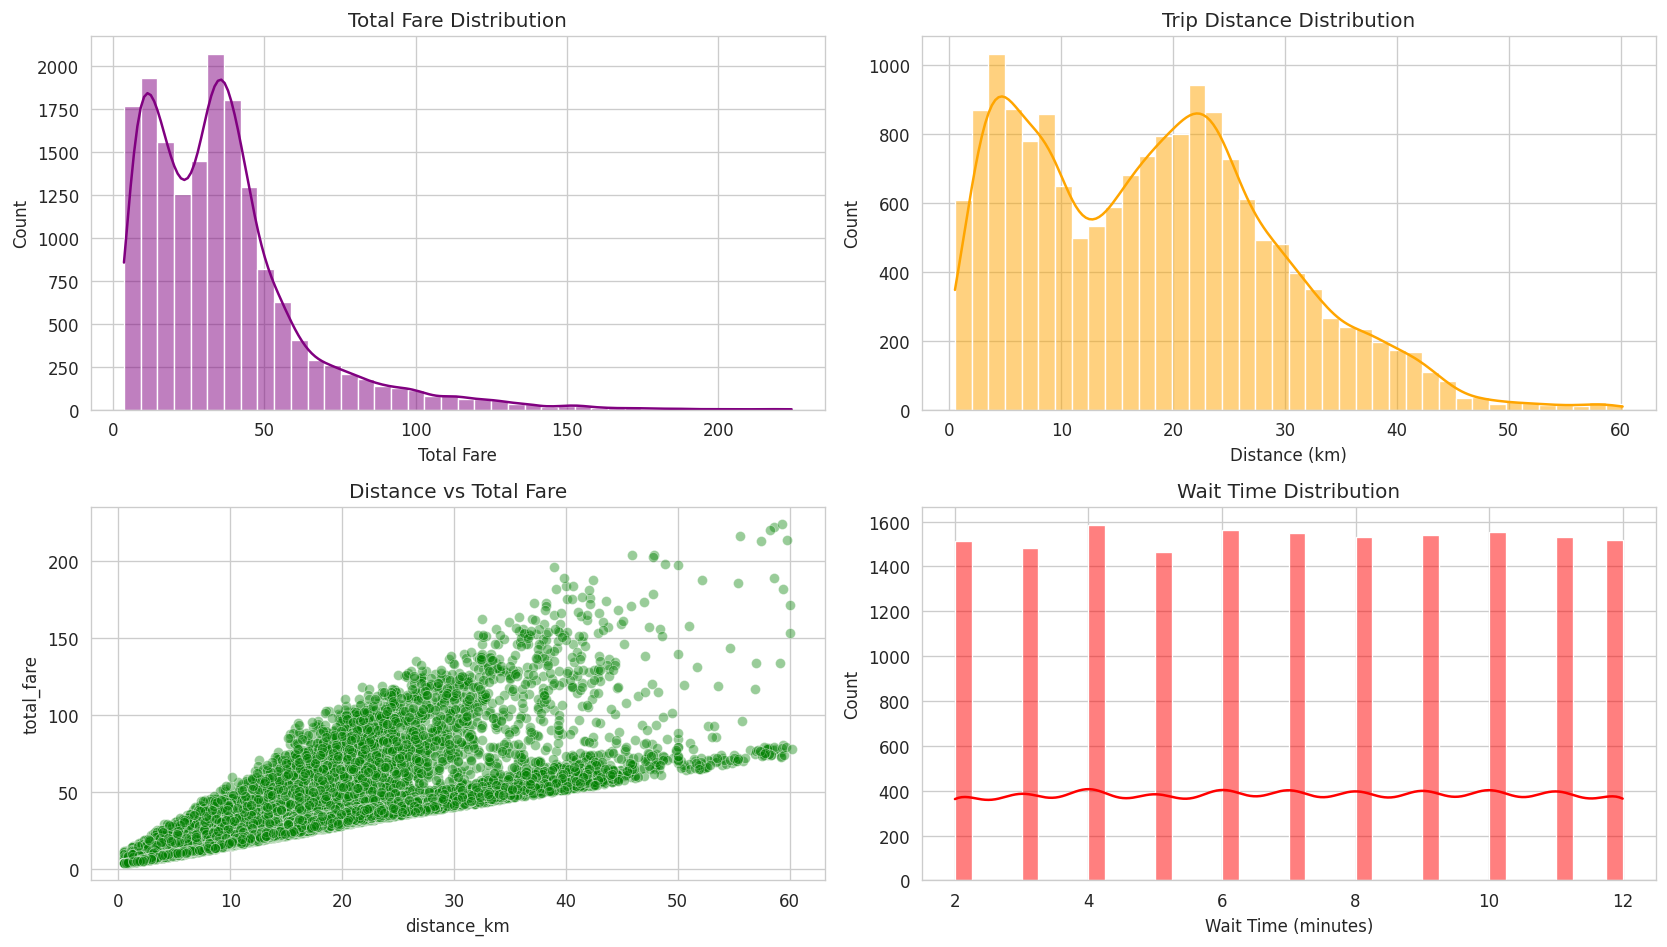

In [18]:
# Completed trips only
completed = trips[trips["is_completed"] == 1]

plt.figure(figsize=(14,8))

# 1. Total Fare Distribution
plt.subplot(2,2,1)
sns.histplot(completed["total_fare"], bins=40, color="purple", kde=True)
plt.title("Total Fare Distribution")
plt.xlabel("Total Fare")

# 2. Distance Distribution
plt.subplot(2,2,2)
sns.histplot(completed["distance_km"], bins=40, color="orange", kde=True)
plt.title("Trip Distance Distribution")
plt.xlabel("Distance (km)")

# 3. Distance vs Fare
plt.subplot(2,2,3)
sns.scatterplot(x="distance_km", y="total_fare", data=completed, color="green", alpha=0.4)
plt.title("Distance vs Total Fare")

# 4. Wait Time Distribution
plt.subplot(2,2,4)
sns.histplot(completed["wait_time_mins"], bins=40, color="red", kde=True)
plt.title("Wait Time Distribution")
plt.xlabel("Wait Time (minutes)")

plt.tight_layout()
plt.show()

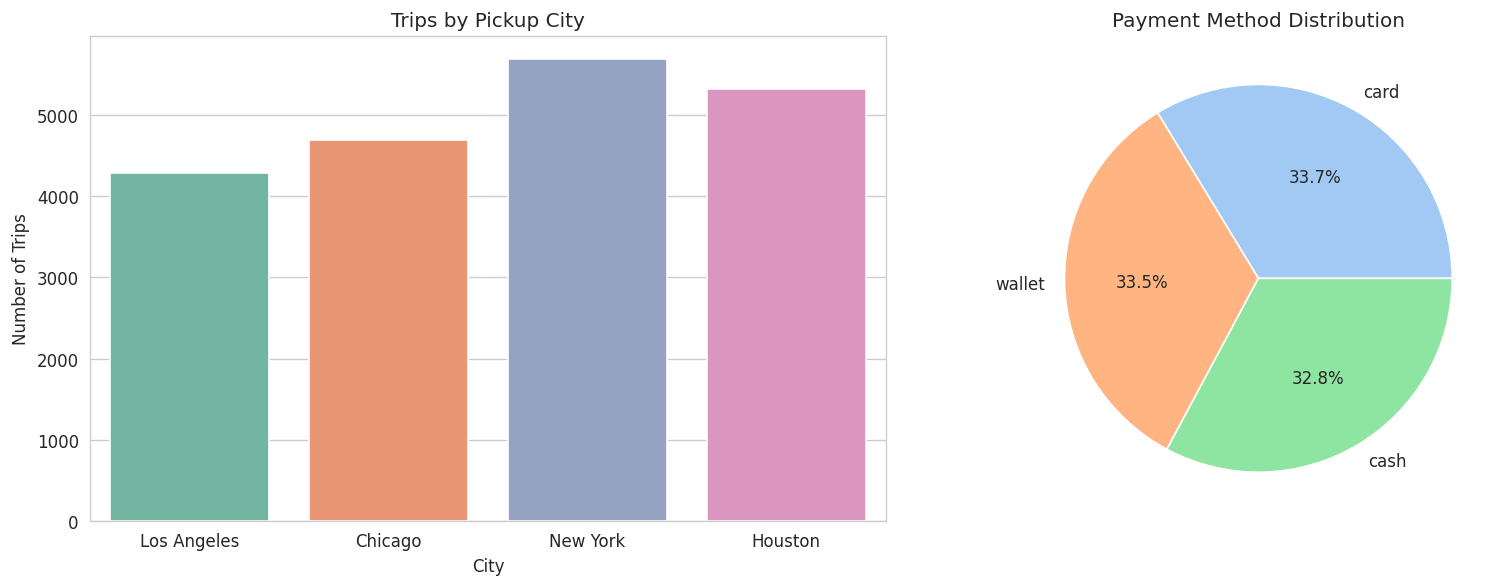

In [19]:
# Join trips with location table
trips_loc = trips.merge(locations, left_on="pickup_location_id", right_on="location_id", how="left")

plt.figure(figsize=(14,5))

# Trips by City
plt.subplot(1,2,1)
sns.countplot(x="city", data=trips_loc, palette="Set2")
plt.title("Trips by Pickup City")
plt.xlabel("City")
plt.ylabel("Number of Trips")

# Payment Method Distribution
plt.subplot(1,2,2)
trips["payment_method"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
    ylabel=""
)
plt.title("Payment Method Distribution")

plt.tight_layout()
plt.show()

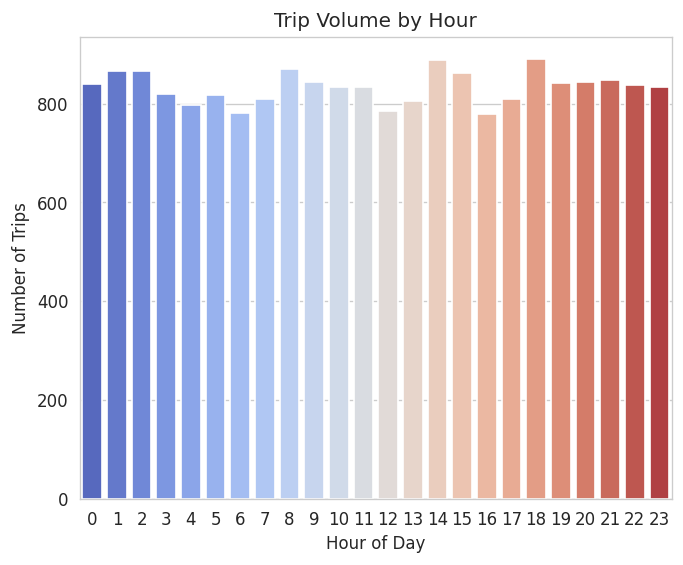

In [20]:
# Temporal Patterns

plt.figure(figsize=(14,5))

# Trips by Hour
plt.subplot(1,2,1)
sns.countplot(x="hour", data=trips, palette="coolwarm")
plt.title("Trip Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

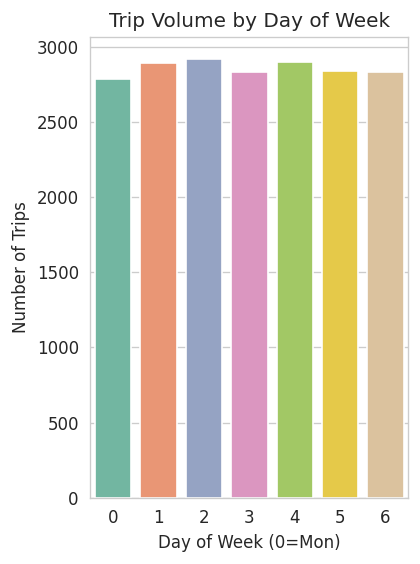

In [21]:
# Trips by Day of Week
plt.subplot(1,2,2)
sns.countplot(x="day_of_week", data=trips, palette="Set2")
plt.title("Trip Volume by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

## # Surge Pricing & Fare by City

Text(0.5, 0, 'Surge Multiplier')

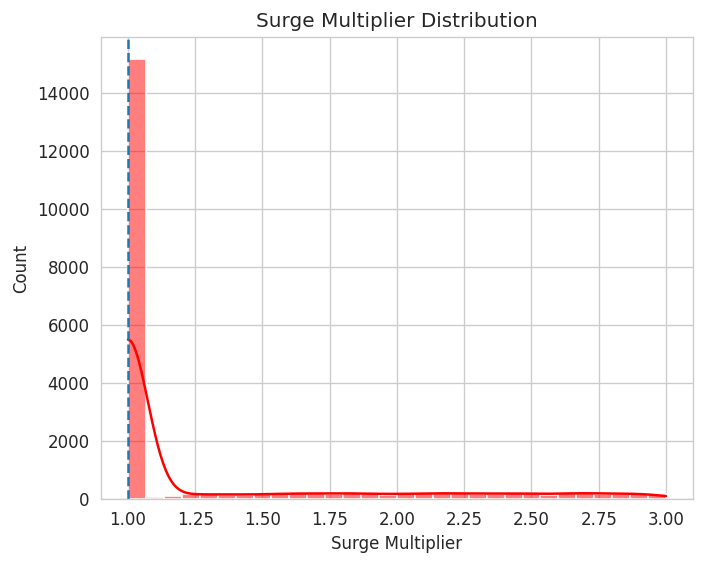

In [22]:
plt.figure(figsize=(14,5))

# 1. Surge Multiplier Distribution
plt.subplot(1,2,1)
sns.histplot(trips["surge_multiplier"], bins=30, color="red", kde=True)
plt.axvline(1, linestyle="--")
plt.title("Surge Multiplier Distribution")
plt.xlabel("Surge Multiplier")


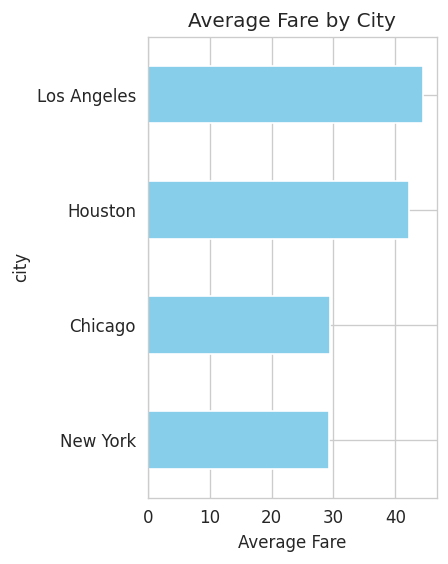

In [23]:
# 2. Average Fare by City
plt.subplot(1,2,2)
fare_city = trips_loc.groupby("city")["total_fare"].mean().sort_values()
fare_city.plot(kind="barh", color="skyblue")
plt.title("Average Fare by City")
plt.xlabel("Average Fare")

plt.tight_layout()
plt.show()

In [24]:
# Surge trip percentage
surge = trips["is_surge"].sum()
percent = trips["is_surge"].mean() * 100
print("Surge trips:", surge, f"({percent:.1f}%)")

Surge trips: 4811 (24.1%)


## # Driver Analysis


Text(0.5, 0, 'Rating')

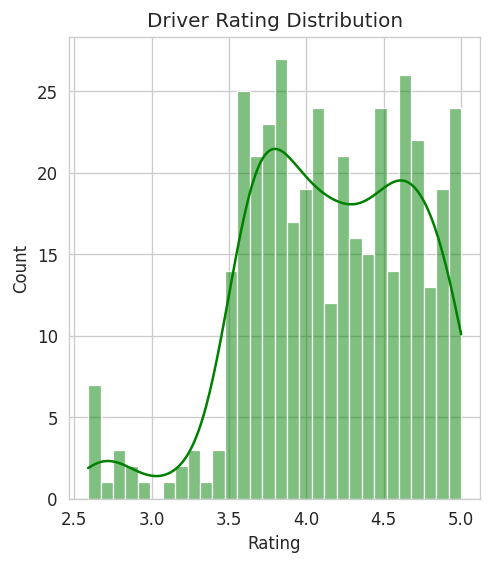

In [25]:
plt.figure(figsize=(15,5))

# 1. Driver Rating Distribution
plt.subplot(1,3,1)
sns.histplot(drivers["rating"], bins=30, color="green", kde=True)
plt.title("Driver Rating Distribution")
plt.xlabel("Rating")


Text(0.5, 0, 'Count')

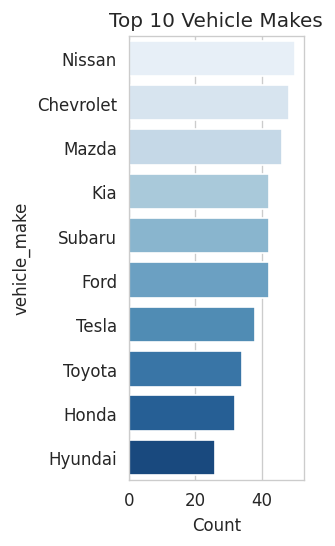

In [26]:
# 2. Top Vehicle Makes
plt.subplot(1,3,2)
sns.countplot(y="vehicle_make", data=drivers,
              order=drivers["vehicle_make"].value_counts().index[:10],
              palette="Blues")
plt.title("Top 10 Vehicle Makes")
plt.xlabel("Count")

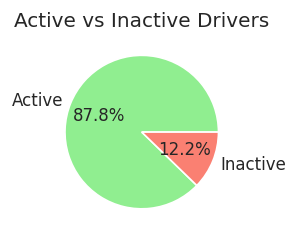

In [27]:
# 3. Active vs Inactive Drivers
plt.subplot(1,3,3)
drivers["is_active"].value_counts().plot.pie(
    labels=["Active","Inactive"],
    autopct="%1.1f%%",
    colors=["lightgreen","salmon"],
    ylabel=""
)
plt.title("Active vs Inactive Drivers")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count')

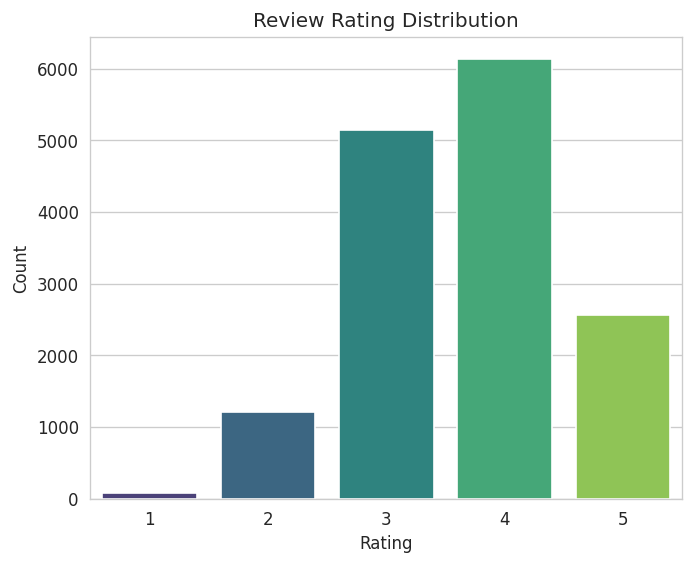

In [28]:
# Reviews & Cancellations Analysis

plt.figure(figsize=(14,5))

# 1. Review Rating Distribution
plt.subplot(1,2,1)
sns.countplot(x="rating", data=reviews, palette="viridis")
plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

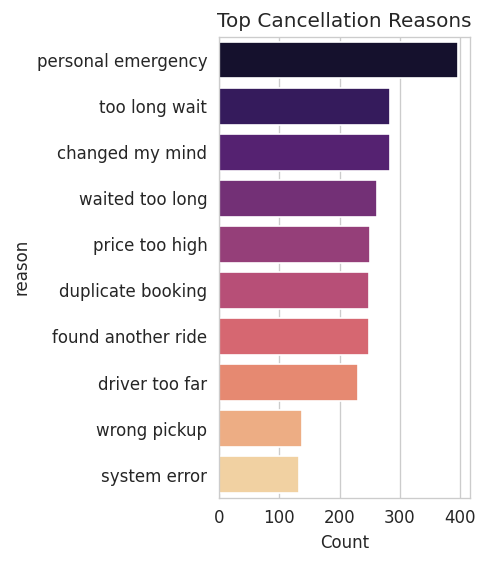

In [29]:
# 2. Top Cancellation Reasons
plt.subplot(1,2,2)
sns.countplot(y="reason", data=cancellations,
              order=cancellations["reason"].value_counts().index[:10],
              palette="magma")
plt.title("Top Cancellation Reasons")
plt.xlabel("Count")

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Average Fare')

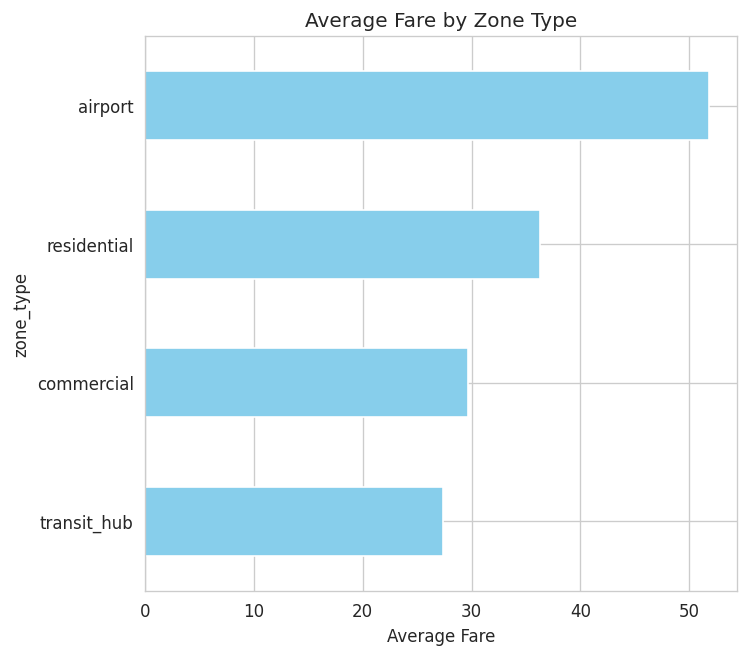

In [30]:
# Zone Type & Correlation Analysis

plt.figure(figsize=(14,6))

# 1. Average Fare by Zone Type
plt.subplot(1,2,1)
zone_fare = trips_loc.groupby("zone_type")["total_fare"].mean().sort_values()
zone_fare.plot(kind="barh", color="skyblue")
plt.title("Average Fare by Zone Type")
plt.xlabel("Average Fare")

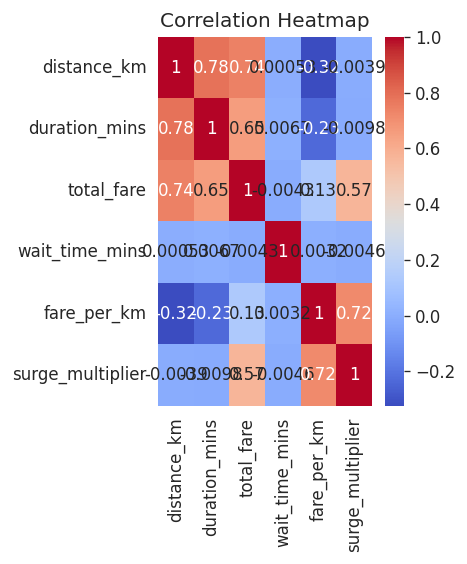

In [31]:
plt.subplot(1,2,2)
num_cols = ["distance_km","duration_mins","total_fare",
            "wait_time_mins","fare_per_km","surge_multiplier"]

corr = trips[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## # Top 10 Drivers by Earnings

In [32]:
print("Top 10 Drivers by Total Earnings")

q1 = """
SELECT d.driver_id,
       COUNT(t.trip_id) AS total_trips,
       SUM(t.total_fare) AS total_earnings
FROM trips t
JOIN drivers d ON t.driver_id = d.driver_id
WHERE t.status = 'completed'
GROUP BY d.driver_id
ORDER BY total_earnings DESC
LIMIT 10
"""

top_drivers = pd.read_sql(q1, conn)
print(top_drivers)


# Revenue by City
print("\nRevenue by City")

q2 = """
SELECT l.city,
       COUNT(t.trip_id) AS trips,
       SUM(t.total_fare) AS total_revenue,
       AVG(t.total_fare) AS avg_fare
FROM trips t
JOIN locations l ON t.pickup_location_id = l.location_id
WHERE t.status = 'completed'
GROUP BY l.city
ORDER BY total_revenue DESC
"""

city_revenue = pd.read_sql(q2, conn)
print(city_revenue)

Top 10 Drivers by Total Earnings
   driver_id  total_trips  total_earnings
0         10           76         3679.84
1        234           74         3484.90
2         57           73         3299.26
3         98           74         3279.39
4        303           64         3269.23
5        337           77         3111.72
6         34           62         3072.33
7        396           69         3047.77
8        100           68         3041.11
9         63           60         3010.65

Revenue by City
          city  trips  total_revenue   avg_fare
0      Houston   4432      188019.38  42.423145
1  Los Angeles   3580      158414.18  44.249771
2     New York   4836      141638.34  29.288325
3      Chicago   3979      116518.02  29.283242


## Feature engineering

In [33]:
# Merge tables
ml_trips = trips.merge(locations, left_on="pickup_location_id", right_on="location_id", how="left")
ml_trips = ml_trips.merge(drivers[["driver_id","rating"]], on="driver_id", how="left")

# Encode categorical variables
le = LabelEncoder()

ml_trips["city_enc"] = le.fit_transform(ml_trips["city"].fillna("Unknown"))
ml_trips["zone_enc"] = le.fit_transform(ml_trips["zone_type"].fillna("Unknown"))
ml_trips["pay_enc"]  = le.fit_transform(ml_trips["payment_method"].fillna("Unknown"))

# Select features and target
features = [
    "distance_km","duration_mins","surge_multiplier","base_fare",
    "city_enc","zone_enc","pay_enc","hour","day_of_week",
    "is_peak_hour","is_weekend","is_surge","rating","wait_time_mins"
]

target = "total_fare"

# Clean dataset
data = ml_trips[features + [target]].dropna()
data = data[data[target] > 0]

X = data[features]
y = data[target]

print("Dataset shape:", X.shape)
print("Average Fare:", y.mean())

Dataset shape: (16827, 14)
Average Fare: 35.92975099542402


## Train test splitting

In [34]:
print("Top Drivers")

q1 = pd.read_sql("""
SELECT d.driver_id, u.name, u.city,
COUNT(t.trip_id) AS total_trips,
SUM(t.total_fare) AS total_earnings
FROM trips t
JOIN drivers d ON t.driver_id = d.driver_id
JOIN users u ON d.user_id = u.user_id
WHERE t.status='completed'
GROUP BY d.driver_id
ORDER BY total_earnings DESC
LIMIT 10
""", conn)

print(q1)

Top Drivers
   driver_id                name         city  total_trips  total_earnings
0         10      Andrew Morales      Houston           76         3679.84
1        234         George Gray  Los Angeles           74         3484.90
2         57  Christopher Watson      Houston           73         3299.26
3         98     Jeffrey Ramirez  Los Angeles           74         3279.39
4        303       Raymond Moore  Los Angeles           64         3269.23
5        337        Justin Young      Houston           77         3111.72
6         34        Charles Cook  Los Angeles           62         3072.33
7        396    Jennifer Johnson  Los Angeles           69         3047.77
8        100         Debra Adams  Los Angeles           68         3041.11
9         63         Nancy Price  Los Angeles           60         3010.65


In [35]:
# Merge tables
ml_trips = trips.merge(
    locations[['location_id','city','zone_type']],
    left_on='pickup_location_id',
    right_on='location_id',
    how='left'
)

ml_trips = ml_trips.merge(
    drivers[['driver_id','rating']],
    on='driver_id',
    how='left'
)

ml_trips.rename(columns={"rating":"driver_rating"}, inplace=True)

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

ml_trips["city_enc"] = le.fit_transform(ml_trips["city"].astype(str))
ml_trips["zone_enc"] = le.fit_transform(ml_trips["zone_type"].astype(str))
ml_trips["pay_enc"] = le.fit_transform(ml_trips["payment_method"].astype(str))

In [37]:
features = [
"distance_km","duration_mins","surge_multiplier","base_fare",
"city_enc","zone_enc","pay_enc","hour","day_of_week",
"is_peak_hour","is_weekend","is_surge","driver_rating"
]

target = "total_fare"

data = ml_trips[features + [target]].dropna()

X = data[features]
y = data[target]

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestRegressor()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2:", r2_score(y_test,pred))
print("MAE:", mean_absolute_error(y_test,pred))

R2: 0.9995775097975539
MAE: 0.15713633392751114


In [39]:
ml_trips["is_completed"] = (ml_trips["status"]=="completed").astype(int)

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

features_clf = features
target_clf = "is_completed"

data = ml_trips[features_clf + [target_clf]].dropna()

X = data[features_clf]
y = data[target_clf]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

clf = RandomForestClassifier()

clf.fit(X_train,y_train)

pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))

Accuracy: 1.0


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

features_clf = features
target_clf = "is_completed"

data = ml_trips[features_clf + [target_clf]].dropna()

X = data[features_clf]
y = data[target_clf]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

clf = RandomForestClassifier()

clf.fit(X_train,y_train)

pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))

Accuracy: 1.0


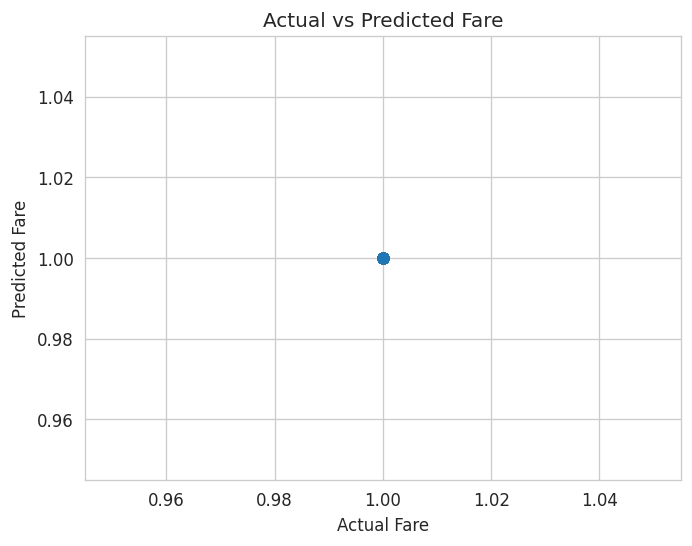

In [42]:
plt.scatter(y_test,pred)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Fare")

plt.show()

## Thank you..pls upvote!!!!!!
